# Task 0: Data Audit and Exploratory Data Analysis

## 1. Introduction

Audit metadata and images, check label imbalance and examples, then validate shared split and training only normalization. The notebook has the decisions and the audit and grouping steps are shown in the code cells below. Existing split/normalization files are read and validated and never silently repaired or rewritten. Creation is only for a missing manifest.

## 2. Library Imports & Setup


In [ ]:
# Import audit libraries, locate the project, and expose shared preprocessing constants.
from IPython.display import display
from pathlib import Path
import json
import os
import sys

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'scripts'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import normalized_mutual_info_score

from scripts.preprocessing import (
    IMAGE_AUDIT_PATH,
    IMAGE_SIZE,
    NORMALISATION_PATH,
    OUTPUT_DIR,
    SEED,
    SPLIT_PATH,
    TARGETS,
    load_metadata,
    load_prediction_template,
    preprocess_image,
)

sns.set_theme(style='whitegrid')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
from scripts.preprocessing import file_sha256

from sklearn.model_selection import GroupShuffleSplit

## 3. Load Metadata

Inspect the catalogue, image coverage and label fields before examining distributions. Literal `NA` is retained as a catalogue value; empty fields remain missing.

In [ ]:
# Compare metadata rows with image files and record coverage, duplicates, and repaired fields.
metadata = load_metadata()
template = load_prediction_template()
train_image_dir = Path(metadata.image_path.iloc[0]).parent
test_image_dir = Path(template.image_path.iloc[0]).parent
train_image_ids = {path.stem for path in train_image_dir.glob('*.jpg')}
test_image_ids = {path.stem for path in test_image_dir.glob('*.jpg')}
repaired_name_mask = metadata.get(
    'productDisplayName_repaired', pd.Series(False, index=metadata.index)
).astype(bool)

# Keep the audit evidence in one reproducible summary object.
coverage_report = {
    'training_rows': len(metadata),
    'unique_training_ids': int(metadata.id.nunique()),
    'duplicate_training_ids': int(metadata.id.duplicated().sum()),
    'training_images_found': int(metadata.has_image.sum()),
    'missing_training_ids': metadata.loc[~metadata.has_image, 'id'].tolist(),
    'orphan_training_image_ids': sorted(train_image_ids - set(metadata.id)),
    'test_rows': len(template),
    'unique_test_ids': int(template.id.nunique()),
    'missing_test_ids': template.loc[
        ~template.image_path.map(lambda value: Path(value).is_file()), 'id'
    ].tolist(),
    'orphan_test_image_ids': sorted(test_image_ids - set(template.id)),
    'styles_train_sha256': file_sha256(train_image_dir.parent / 'styles_train.csv'),
    'styles_prediction_sha256': file_sha256(test_image_dir.parent / 'styles_prediction.csv'),
    'blank_labels': {target: int(metadata[target].str.strip().eq('').sum()) for target in TARGETS},
    'repaired_product_display_names': int(repaired_name_mask.sum()),
    'repaired_product_display_name_ids': metadata.loc[repaired_name_mask, 'id'].tolist(),
}
coverage_report

{'training_rows': 38617,
 'unique_training_ids': 38617,
 'duplicate_training_ids': 0,
 'training_images_found': 38612,
 'missing_training_ids': ['12347', '39401', '39403', '39410', '39425'],
 'orphan_training_image_ids': [],
 'test_rows': 5829,
 'unique_test_ids': 5829,
 'missing_test_ids': [],
 'orphan_test_image_ids': [],
 'styles_train_sha256': '54D503743F79F22BF03F9E2C216B53E75D5F2129EDA5934CFA25C642C70AF44D',
 'styles_prediction_sha256': '7F83F219D0FB7F2EC86B8B5C0BA28C2CFADD8F8E6E85A36C9919C9AB5C41315E',
 'blank_labels': {'articleType': 0, 'season': 20, 'gender': 0, 'usage': 1},
 'repaired_product_display_names': 21,
 'repaired_product_display_name_ids': ['3413',
  '3418',
  '3428',
  '4854',
  '23100',
  '23101',
  '23103',
  '23107',
  '23108',
  '23109',
  '23110',
  '23111',
  '23112',
  '23114',
  '23115',
  '23116',
  '23117',
  '23118',
  '23124',
  '23127',
  '44065']}

## 4. Exploratory Data Analysis (EDA)

Inspect image validity, duplicate groups, class support, relationships and visual examples. Validate the frozen split and training-only normalization before model development.

### 4.1. Image Validity & Duplicate Audit

Decode images and compute content hashes to detect corrupt files and duplicates. Use the displayed audit counts in the final analysis.

In [ ]:
# Decode every available image once and cache its hash, dimensions, colour mode, and any error.
def load_image_audit(metadata, force=False):
    available = metadata.loc[metadata.has_image]
    if force or not IMAGE_AUDIT_PATH.exists():
        rows = []

        # Read each file defensively so one corrupt image does not stop the audit.
        for row in available.itertuples(index=False):
            result = dict(id=row.id, sha256='', width='', height='', mode='', decode_error='')
            try:
                digest = file_sha256(row.image_path).lower()
                with Image.open(row.image_path) as image:
                    image.load()
                    result.update(
                        sha256=digest, width=image.width, height=image.height, mode=image.mode
                    )
            except (OSError, UnidentifiedImageError) as error:
                result['decode_error'] = type(error).__name__
            rows.append(result)
        IMAGE_AUDIT_PATH.parent.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(rows).to_csv(IMAGE_AUDIT_PATH, index=False)

    # Validate the cache against current usable IDs before trusting it.
    audit = pd.read_csv(IMAGE_AUDIT_PATH, dtype={'id': 'string'}, keep_default_na=False)
    if audit.id.duplicated().any() or set(audit.id) != set(available.id):
        raise ValueError('Cached image audit does not match available IDs; repeat the full audit')
    if (audit.decode_error.eq('') & audit.sha256.eq('')).any():
        raise ValueError('Decoded audit rows must have a SHA-256 hash')
    return audit

In [ ]:
# Use the environment setting to decide whether the cached image audit must be rebuilt.
audit_setting = os.environ.get('FASHION_RUN_FULL_AUDIT', 'auto').strip().lower()
force_audit = audit_setting in {'1', 'true', 'yes'}
image_audit = load_image_audit(metadata, force=force_audit)
print(f'Audit rows: {len(image_audit):,}; forced rescan: {force_audit}')

Audit rows: 38,612; forced rescan: False


In [ ]:
# Remove unreadable images, detect exact duplicates, and summarize conflicting labels.
usable_audit = image_audit.loc[image_audit.decode_error.eq('') & image_audit.sha256.ne('')]
usable_metadata = metadata.merge(usable_audit[['id', 'sha256']], on='id', validate='one_to_one')
hash_counts = usable_audit.sha256.value_counts()

# Treat matching SHA-256 hashes as exact duplicate image content.
duplicate_hashes = hash_counts.loc[hash_counts.gt(1)].index
duplicate_rows = usable_metadata.loc[usable_metadata.sha256.isin(duplicate_hashes)]
conflict_rows = []

# Summarize class support and identify rare labels for every target.
for target in TARGETS:
    counts = duplicate_rows.groupby('sha256')[target].nunique()
    conflicts = counts.loc[counts.gt(1)].index
    conflict_rows.append(
        {
            'target': target,
            'conflicting_hash_groups': len(conflicts),
            'rows_in_conflicting_groups': int(duplicate_rows.sha256.isin(conflicts).sum()),
        }
    )
duplicate_conflict_summary = pd.DataFrame(conflict_rows).set_index('target')
lost_labels = {}
for target in TARGETS:
    original = set(metadata.loc[metadata[target].str.strip().ne(''), target])
    lost_labels[target] = sorted(original - set(usable_metadata[target]))
audit_report = {
    **coverage_report,
    'decoded_images': int(image_audit.decode_error.eq('').sum()),
    'decode_errors': image_audit.loc[image_audit.decode_error.ne(''), 'id'].tolist(),
    'exact_duplicate_hash_groups': len(duplicate_hashes),
    'rows_in_exact_duplicate_groups': len(duplicate_rows),
    'labels_lost_after_image_cleaning': lost_labels,
    'image_modes': image_audit['mode'].value_counts().to_dict(),
}
report_path = OUTPUT_DIR / 'audit.json'
if not report_path.exists() or json.loads(report_path.read_text()) != audit_report:
    report_path.write_text(json.dumps(audit_report, indent=2), encoding='utf-8')
display(audit_report)
display(duplicate_conflict_summary)

{'training_rows': 38617,
 'unique_training_ids': 38617,
 'duplicate_training_ids': 0,
 'training_images_found': 38612,
 'missing_training_ids': ['12347', '39401', '39403', '39410', '39425'],
 'orphan_training_image_ids': [],
 'test_rows': 5829,
 'unique_test_ids': 5829,
 'missing_test_ids': [],
 'orphan_test_image_ids': [],
 'styles_train_sha256': '54D503743F79F22BF03F9E2C216B53E75D5F2129EDA5934CFA25C642C70AF44D',
 'styles_prediction_sha256': '7F83F219D0FB7F2EC86B8B5C0BA28C2CFADD8F8E6E85A36C9919C9AB5C41315E',
 'blank_labels': {'articleType': 0, 'season': 20, 'gender': 0, 'usage': 1},
 'repaired_product_display_names': 21,
 'repaired_product_display_name_ids': ['3413',
  '3418',
  '3428',
  '4854',
  '23100',
  '23101',
  '23103',
  '23107',
  '23108',
  '23109',
  '23110',
  '23111',
  '23112',
  '23114',
  '23115',
  '23116',
  '23117',
  '23118',
  '23124',
  '23127',
  '44065'],
 'decoded_images': 38611,
 'decode_errors': ['8121'],
 'exact_duplicate_hash_groups': 636,
 'rows_in_exac

,conflicting_hash_groups,rows_in_conflicting_groups
target,,
articleType,7,14
season,8,16
gender,7,15
usage,3,6


#### Audit Observations

The cached audit includes 38,612 available training images. Five of the 38,617 unique metadata IDs have no image (12347, 39401, 39403, 39410 and 39425); image 8121 fails decoding. This makes 38,611 usable images after removing these six records. There are no duplicate metadata IDs and no orphan image files. There are 5,829 prediction IDs, each one of them unique and attached to a file. But just because the file exists does not mean that it can be decoded. Parsing fixes 21 product-description fields without changing the source CSV.

Exact hashes identify 1,399 rows in 636 duplicate groups. Some of the groups with the same image have conflicting labels, 7 for article type, 8 for season, 7 for gender and 3 for usage. These counts may overlap between targets. The ambiguity that image pixels alone cannot resolve is introduced by such conflicts. Keeping duplicate/product-name groups together in one partition prevents identical images from artificially inflating evaluation scores; it does not remove label noise.

Image cleaning also removes the only working way back to the original Suits category: there is no Suits image left for supervised learning. Missing target values are handled separately, so a record with an empty season can still contribute to another target. These observations are of the recycled audit and current saved outputs, not a new forced image rescan.


### 4.2. Target Distributions & Missing Labels

Compare class support, missing values and the share of the largest class. This motivates reporting macro-F1 alongside accuracy.

,classes,blank,largest_class_share,classes_below_10
target,,,,
articleType,124,0,0.175598,32
season,4,20,0.495841,0
gender,5,0,0.541607,0
usage,9,1,0.767547,1


images
target      label                      
articleType Ties and Cufflinks        1
            Shoe Laces                1
            Cushion Covers            1
            Body Wash and Scrub       1
            Ipad                      1
            Lounge Tshirts            1
            Key chain                 2
            Lehenga Choli             2
            Baby Dolls                2
            Concealer                 2
            Shapewear                 2
            Robe                      2
            Rain Trousers             2
            Rain Jacket               2
            Hat                       3
season      Spring                 1566
            Winter                 7378
            Fall                  10512
            Summer                19135
gender      Girls                   645
            Boys                    814
            Unisex                 2080
            Women                 14160
            Men                   20912
usage       Home                      1
            Party                    13
            Travel                   25
            Smart Casual             55
            NA                       71
            Formal                 2300
            Ethnic                 2570
            Sports                 3940
            Casual                29635

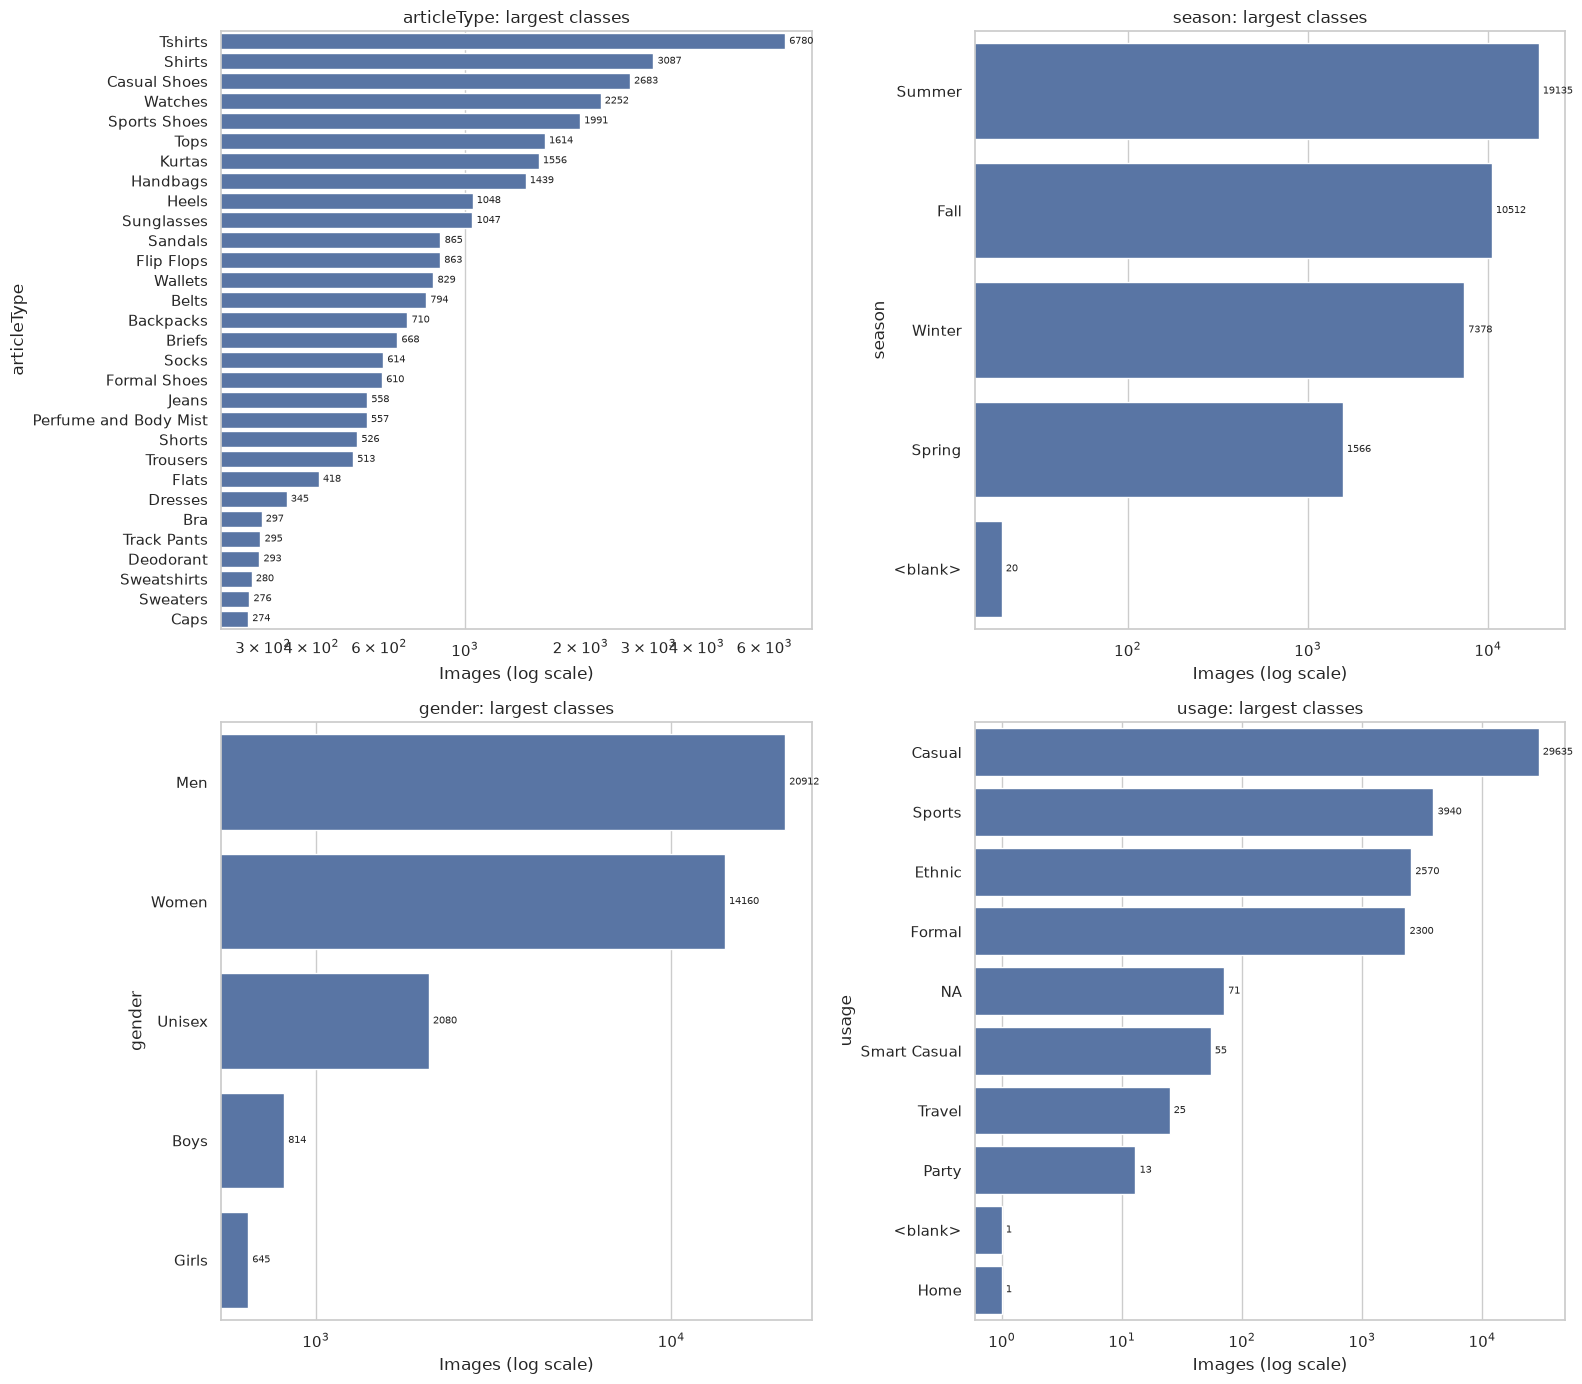

In [ ]:
# Visualize class imbalance and tabulate rare or missing labels for every prediction target.
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for target, axis in zip(TARGETS, axes.ravel()):
    counts = usable_metadata[target].replace('', '<blank>').value_counts().head(30)
    sns.barplot(x=counts.values, y=counts.index, ax=axis)
    axis.set_xscale('log')
    axis.set_title(f'{target}: largest classes')
    axis.set_xlabel('Images (log scale)')
    axis.bar_label(axis.containers[0], fmt='%d', padding=3, fontsize=7)
plt.tight_layout()
figures = ROOT / 'figures'
figures.mkdir(exist_ok=True)
fig.savefig(figures / 'target_distributions.png', dpi=220, bbox_inches='tight')

# Summarize imbalance numerically after drawing the largest classes.
distribution_rows = []
rare_counts = {}

# Check duplicate groups independently for every prediction target.
for target in TARGETS:
    values = usable_metadata[target]
    counts = values.loc[values.str.strip().ne('')].value_counts()
    distribution_rows.append(
        {
            'target': target,
            'classes': len(counts),
            'blank': int(values.str.strip().eq('').sum()),
            'largest_class_share': counts.iloc[0] / counts.sum(),
            'classes_below_10': int(counts.lt(10).sum()),
        }
    )
    rare_counts[target] = counts.sort_values().head(15).rename('images')
display(pd.DataFrame(distribution_rows).set_index('target'))
display(pd.concat(rare_counts, names=['target', 'label']).to_frame())

#### Distribution Observations

The usable image pool has 124 article types, four seasons, five audience labels and nine usage labels. There are 32 classes of article type with less than ten examples, but the largest class accounts for 17.56% of the images. Singleton categories such as Shoe Laces and Cushion Covers cannot provide both training and independent evaluation examples. Note that their presence in the output vocabulary does not imply demonstrated predictive coverage.

Summer dominates the season with 19,135 examples (49.58% of nonblank season labels), while Spring has 1,566. There are 20,912 instances of men (54.16% of the pool of images), vs 645 girls and 814 boys. Usage is also heavily skewed. Casual has 29,635 examples (76.75% of nonblank usage labels), Party 13, Travel 25, Smart Casual 55 and Home just one. The literal NA class has 71 instances and is a valid label, unlike the single blank usage field. Twenty season fields are empty.

These are full-pool descriptive counts, not training-only class weights. Accuracy can hide bad minority recognition, especially for occasion. So accuracy is not enough. Supported-class macro-F1 and per-class precision/recall are needed. Any weighting must be derived from the training partition alone and estimates for categories with very small validation support are still unstable.


### 4.3. Target Relationships & Confounding

Cross-tabulations and normalized mutual information indicate relationships between labels. These associations can support prediction but can also encourage shortcuts.

In [ ]:
# Measure associations between labels and identify article types concentrated in one season.
# Normalized mutual information quantifies association without assuming numeric labels.
relationship_summary = pd.DataFrame(
    [
        {
            'relationship': f'articleType vs {target}',
            'normalized_mutual_information': normalized_mutual_info_score(
                usable_metadata.loc[usable_metadata[target].str.strip().ne(''), 'articleType'],
                usable_metadata.loc[usable_metadata[target].str.strip().ne(''), target],
            ),
        }
        for target in ('season', 'gender', 'usage')
    ]
).set_index('relationship')
season_by_type = pd.crosstab(usable_metadata.articleType, usable_metadata.season, normalize='index')
season_support = usable_metadata.articleType.value_counts()
concentrated_season_types = (
    season_by_type.assign(
        support=season_support,
        dominant_share=season_by_type.max(axis=1),
    )
    .loc[lambda frame: frame.support.ge(20)]
    .sort_values('dominant_share', ascending=False)
    .head(15)
)
display(relationship_summary)
concentrated_season_types.style.background_gradient(cmap='Blues')

pd.crosstab(
    usable_metadata.gender, usable_metadata.usage, normalize='index'
).style.background_gradient(cmap='Purples')

,normalized_mutual_information
relationship,
articleType vs season,0.173752
articleType vs gender,0.193672
articleType vs usage,0.253296


usage,,Casual,Ethnic,Formal,Home,NA,Party,Smart Casual,Sports,Travel
gender,,,,,,,,,,
Boys,0.000000,0.961916,0.012285,0.000000,0.000000,0.000000,0.000000,0.000000,0.025799,0.000000
Girls,0.000000,0.984496,0.012403,0.000000,0.000000,0.000000,0.000000,0.000000,0.003101,0.000000
Men,0.000048,0.750048,0.004304,0.104868,0.000000,0.001052,0.000000,0.002104,0.137529,0.000048
Unisex,0.000000,0.845192,0.000000,0.000481,0.000481,0.008654,0.000000,0.000000,0.135577,0.009615
Women,0.000000,0.760876,0.173870,0.007486,0.000000,0.002189,0.000918,0.000777,0.053602,0.000282


### 4.4. Visual Inspection

Inspect representative and problematic images alongside metadata. Describe ambiguity, backgrounds and other visual factors that may influence classification.

,id,articleType,season,gender,usage,issue
9089,12347,Suits,Winter,Men,Casual,missing image
29792,39401,Jeans,Winter,Men,Casual,missing image
29793,39403,Shirts,Summer,Men,Casual,missing image
29795,39410,Shirts,Summer,Men,Casual,missing image
29799,39425,Tshirts,Spring,Men,Casual,missing image


,id,decode_error,issue
5547,8121,OSError,decode error


,width,height
count,38611.000000,38611.000000
mean,59.998550,79.997022
std,0.100751,0.230910
min,53.000000,60.000000
25%,60.000000,80.000000
50%,60.000000,80.000000
75%,60.000000,80.000000
max,60.000000,80.000000


mode
RGB    38268
L        343
Name: count, dtype: int64

images
width height        
60    80       38594
53    80           8
60    60           5
      77           2
      76           1
      75           1

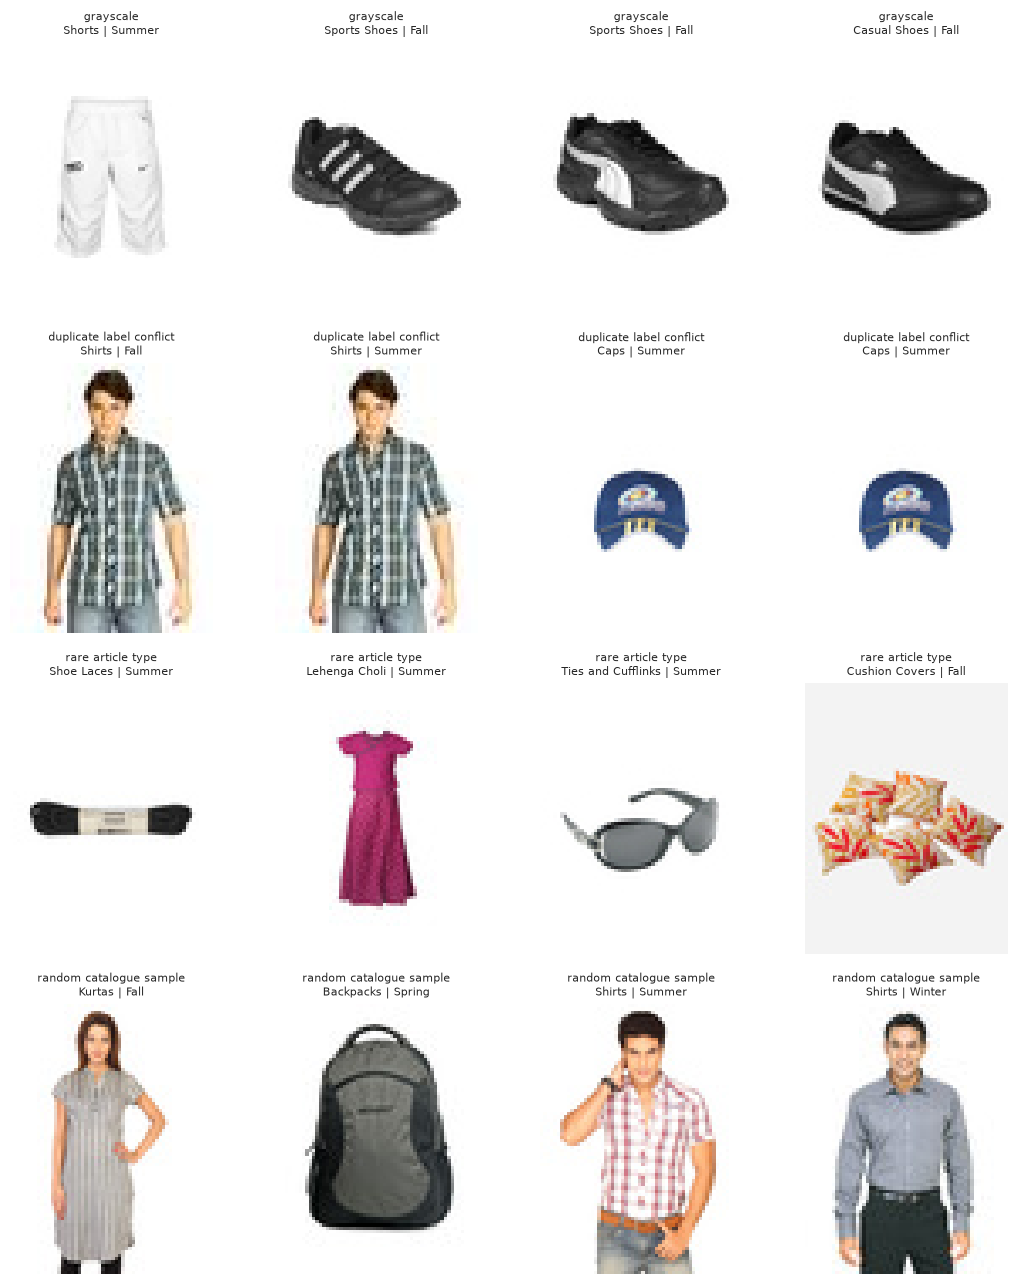

In [ ]:
# Inspect representative data-quality cases and summarize image sizes and colour modes.
missing_examples = metadata.loc[
    ~metadata.has_image, ['id', 'articleType', 'season', 'gender', 'usage']
].assign(issue='missing image')
decode_examples = image_audit.loc[image_audit.decode_error.ne(''), ['id', 'decode_error']].assign(
    issue='decode error'
)
display(missing_examples)
display(decode_examples)

# Choose examples that illustrate grayscale data, conflicts, rare labels, and normal cases.
grayscale_ids = image_audit.loc[image_audit['mode'].eq('L'), 'id'].head(4)
grayscale_examples = usable_metadata.loc[usable_metadata.id.isin(grayscale_ids)].assign(
    example_reason='grayscale'
)
conflicting_hashes = (
    (duplicate_rows.groupby('sha256')[list(TARGETS)].nunique().gt(1).any(axis=1))
    .loc[lambda values: values]
    .index[:2]
)
conflict_examples = (
    duplicate_rows.loc[duplicate_rows.sha256.isin(conflicting_hashes)]
    .groupby('sha256')
    .head(2)
    .assign(example_reason='duplicate label conflict')
)
article_support = usable_metadata.articleType.value_counts()
rare_examples = (
    usable_metadata.loc[
        usable_metadata.articleType.isin(article_support.loc[article_support.le(2)].index)
    ]
    .drop_duplicates('articleType')
    .head(4)
    .assign(example_reason='rare article type')
)
chosen_ids = set(pd.concat([grayscale_examples, conflict_examples, rare_examples]).id)
common_examples = (
    usable_metadata.loc[~usable_metadata.id.isin(chosen_ids)]
    .sample(4, random_state=SEED)
    .assign(example_reason='random catalogue sample')
)
sample = (
    pd.concat(
        [grayscale_examples, conflict_examples, rare_examples, common_examples], ignore_index=True
    )
    .drop_duplicates('id')
    .head(16)
)
fig, axes = plt.subplots(4, 4, figsize=(11, 13))
for (_, row), axis in zip(sample.iterrows(), axes.ravel()):
    with Image.open(row.image_path) as image:
        axis.imshow(image.convert('RGB'))
    axis.set_title(f'{row.example_reason}\n{row.articleType} | {row.season}', fontsize=8)
    axis.axis('off')
for axis in axes.ravel()[len(sample) :]:
    axis.axis('off')
plt.tight_layout()

dimensions = image_audit.loc[image_audit.decode_error.eq(''), ['width', 'height']].apply(
    pd.to_numeric
)
display(dimensions.describe())
display(image_audit.loc[image_audit.decode_error.eq(''), 'mode'].value_counts())
display(dimensions.value_counts().rename('images').head(10).to_frame())

### 4.5. Group-Isolated Split Validation

The following functions group related rows, ensure label coverage and validate the frozen manifest. Existing valid assignments are reused; group isolation is more important than matching exact percentages.

#### Build Group Keys

In [ ]:
# Group rows connected by product name or identical image hash so related items cannot leak across splits.
def build_group_keys(frame, audit):
    frame = frame.merge(audit[['id', 'sha256', 'decode_error']], on='id', how='left')
    frame = frame.loc[frame.has_image & frame.decode_error.eq('')].reset_index(drop=True)
    frame['name_key'] = (
        frame.productDisplayName.astype('string')
        .str.lower()
        .str.replace('\\W+', ' ', regex=True)
        .str.strip()
    )
    frame.loc[frame.name_key.eq(''), 'name_key'] = frame.id

    # Use union-find to merge transitive name/hash connections into one group.
    parent = list(range(len(frame)))

    def find(index):
        while parent[index] != index:
            parent[index] = parent[parent[index]]
            index = parent[index]
        return index

    def union(left, right):
        left_root, right_root = (find(left), find(right))
        if left_root != right_root:
            parent[right_root] = left_root

    # Connect every pair of rows sharing either normalized name or exact image hash.
    for column in ('name_key', 'sha256'):
        values = frame[column].astype('string').fillna('')
        for value, indices in values.groupby(values, sort=False).groups.items():
            if not value or len(indices) < 2:
                continue
            first = int(indices[0])
            for index in indices[1:]:
                union(first, int(index))
    frame['group_key'] = [f'group_{find(index)}' for index in range(len(frame))]
    return frame

#### Enforce Training Label Coverage

In [ ]:
# Move complete groups when necessary so every evaluated label has a training example.
def enforce_training_label_coverage(frame, split_frame):
    """Move whole duplicate groups to train when a label has no train example."""
    revised = split_frame.copy()
    changes = []

    # Check training-label coverage independently for every prediction target.
    for target in TARGETS:
        joined = frame[['id', target]].merge(revised, on='id', validate='one_to_one')
        valid = joined[target].astype('string').str.strip().ne('')
        train_labels = set(joined.loc[valid & joined.split.eq('train'), target])
        missing_labels = sorted(set(joined.loc[valid, target]) - train_labels)
        for label in missing_labels:
            groups = joined.loc[valid & joined[target].eq(label), 'group_key'].unique()
            move_mask = revised.group_key.isin(groups) & ~revised.split.eq('train')
            changes.append(
                {
                    'target': target,
                    'label': label,
                    'groups_moved': int(len(groups)),
                    'rows_moved': int(move_mask.sum()),
                }
            )
            revised.loc[revised.group_key.isin(groups), 'split'] = 'train'
    return (revised, pd.DataFrame(changes))

#### Create Frozen Split

In [ ]:
# Create a 70/15/15 group-aware train, validation, and test assignment.
def create_frozen_split(frame, audit):
    grouped = build_group_keys(frame, audit)

    # First reserve 30% of complete groups as a combined holdout.
    first = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=SEED)
    _, holdout_index = next(first.split(grouped, groups=grouped.group_key))
    holdout = grouped.iloc[holdout_index]

    # Then divide holdout groups equally into validation and test partitions.
    second = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED + 1)
    _, test_relative = next(second.split(holdout, groups=holdout.group_key))
    grouped['split'] = 'train'
    grouped.loc[grouped.id.isin(holdout.id), 'split'] = 'validation'
    grouped.loc[grouped.id.isin(holdout.iloc[test_relative].id), 'split'] = 'test'
    return grouped[['id', 'group_key', 'split']]

#### Validate Frozen Split

In [ ]:
# Reject stale or leaking split manifests before any model uses them.
def validate_frozen_split(metadata, audit, splits):
    grouped = build_group_keys(metadata, audit)
    if splits.id.duplicated().any() or set(splits.id) != set(grouped.id):
        raise ValueError('Frozen split IDs differ from the usable audited images')
    if splits.group_key.isna().any() or splits.group_key.eq('').any():
        raise ValueError('Every split row needs a group key')
    if set(splits.split) != {'train', 'validation', 'test'}:
        raise ValueError('Expected nonempty train, validation and test partitions')

    # The same duplicate/product group must never occur in multiple partitions.
    if splits.groupby('group_key').split.nunique().gt(1).any():
        raise ValueError('A frozen group crosses partitions')

    # Recompute connections to catch a manifest that assigns different group keys
    # to rows sharing a name/hash, including transitive chains.
    joined = grouped[['id', 'group_key']].merge(
        splits[['id', 'split']], on='id', validate='one_to_one'
    )
    if joined.groupby('group_key').split.nunique().gt(1).any():
        raise ValueError('Related product names or duplicate images cross partitions')
    _, changes = enforce_training_label_coverage(metadata, splits)
    if not changes.empty:
        raise ValueError(
            'Frozen training split lacks evaluated labels; review the manifest explicitly'
        )

#### Load Or Create Split

In [ ]:
# Reuse a validated frozen split, or create and save it on the first run.
def load_or_create_split(metadata, audit):
    if SPLIT_PATH.exists():
        splits = pd.read_csv(SPLIT_PATH, dtype={'id': 'string'})
        validate_frozen_split(metadata, audit, splits)
        return splits
    splits = create_frozen_split(metadata, audit)
    splits, _ = enforce_training_label_coverage(metadata, splits)
    validate_frozen_split(metadata, audit, splits)
    SPLIT_PATH.parent.mkdir(parents=True, exist_ok=True)
    splits.to_csv(SPLIT_PATH, index=False)
    return splits

In [ ]:
# Summarize split sizes, group isolation, label coverage, and distribution drift.
splits = load_or_create_split(metadata, image_audit)
print('Frozen split validated; existing assignments preserved.')
display(splits['split'].value_counts())

split_metadata = usable_metadata.merge(splits, on='id', validate='one_to_one')
split_counts = splits.split.value_counts().reindex(['train', 'validation', 'test'])
split_summary = pd.DataFrame(
    {
        'rows': split_counts,
        'percent': 100 * split_counts / len(splits),
        'groups': splits.groupby('split').group_key.nunique().reindex(split_counts.index),
    }
)

# Measure how closely each partition preserves the full class distribution.
split_quality_rows = []

# Evaluate label coverage and class-distribution drift for every target.
for target in TARGETS:
    valid = split_metadata[target].str.strip().ne('')
    target_frame = split_metadata.loc[valid]
    overall_share = target_frame[target].value_counts(normalize=True)
    train_labels = set(target_frame.loc[target_frame.split.eq('train'), target])
    for split_name in ('train', 'validation', 'test'):
        partition = target_frame.loc[target_frame.split.eq(split_name), target]
        partition_share = partition.value_counts(normalize=True).reindex(
            overall_share.index, fill_value=0
        )
        split_quality_rows.append(
            {
                'target': target,
                'split': split_name,
                'usable_rows': len(partition),
                'labels_present': partition.nunique(),
                'labels_absent_from_training': len(set(partition) - train_labels),
                'max_class_share_drift_pp': 100 * (partition_share - overall_share).abs().max(),
            }
        )
split_quality = pd.DataFrame(split_quality_rows)
display(split_summary.round({'percent': 2}))
display(
    pd.DataFrame(
        {
            'groups': [splits.group_key.nunique()],
            'largest_group_rows': [splits.groupby('group_key').size().max()],
            'groups_crossing_splits': [splits.groupby('group_key').split.nunique().gt(1).sum()],
        }
    )
)
split_quality.round({'max_class_share_drift_pp': 2})

Frozen split validated; existing assignments preserved.


split
train         27051
validation     5842
test           5718
Name: count, dtype: int64

,rows,percent,groups
split,,,
train,27051,70.06,18987
validation,5842,15.13,4064
test,5718,14.81,4067


,groups,largest_group_rows,groups_crossing_splits
0,27118,82,0


,target,split,usable_rows,labels_present,labels_absent_from_training,max_class_share_drift_pp
0,articleType,train,27051,124,0,0.26
1,articleType,validation,5842,104,0,0.80
2,articleType,test,5718,101,0,0.71
3,season,train,27038,4,0,0.28
4,season,validation,5838,4,0,0.57
5,season,test,5715,4,0,0.73
6,gender,train,27051,5,0,0.32
7,gender,validation,5842,5,0,0.54
8,gender,test,5718,5,0,1.07
9,usage,train,27050,9,0,0.20


#### Split Observations

The existing manifests were validated and retained: 27,051 training images (70.06%), 5,842 validation images (15.13%) and 5,718 test images (14.81%). They have 27,118 connected groups, distributed as 18,987 / 4,064 / 4,067 and no group crosses a partition. This is why the group allocation can not get exact percentages on the image level. The largest group has 82 images.

All classes are available for training. Article-type coverage drops from 124 training classes to 104 in full validation and 101 in test; usage has nine training classes but eight in each evaluation partition. Each partition has all the four seasons and five types of audiences. season 27,038/5,838/5,715 usage 27,050/5,842/5,718 blank-label filtering. The maximum class-share differences from the full pool are modest (at most 1.40 percentage points across the shown target/partition combinations), but this does not constitute adequate support for all rare classes.

The full validation counts above differ from the smaller model-selection perspective in Tasks 1-3, which separates out groups for calibration and review-policy choice. Group isolation fixes the related-image leakage; it does not make internal test untouched after prior development exposure. In Tasks 1-4, we continue using these frozen manifests rather than regenerating favorable splits.


### 4.6. Training-Only RGB Normalization

Compute channel statistics from training images only, then reuse them unchanged for validation, test and application inference.

In [ ]:
# Calculate per-channel RGB mean and standard deviation from training pixels only.
def compute_training_normalisation(frame, split_frame):
    joined = frame.merge(split_frame, on='id', validate='one_to_one')
    paths = joined.loc[joined.split.eq('train'), 'image_path']

    # Accumulate first and second moments without holding all float images in memory.
    channel_sum = np.zeros(3, dtype=np.float64)
    channel_square_sum = np.zeros(3, dtype=np.float64)
    pixel_count = 0
    for path in paths:
        with Image.open(path) as image:
            array = preprocess_image(image).astype(np.float64)
        channel_sum += array.sum(axis=(0, 1))
        channel_square_sum += np.square(array).sum(axis=(0, 1))
        pixel_count += array.shape[0] * array.shape[1]
    mean = channel_sum / pixel_count
    std = np.sqrt(channel_square_sum / pixel_count - np.square(mean))
    return {'mean': mean.tolist(), 'std': std.tolist(), 'image_size': list(IMAGE_SIZE)}

In [ ]:
# Reuse frozen normalization statistics and validate their shape and numerical range.
def load_or_compute_normalisation(metadata, splits):
    if NORMALISATION_PATH.exists():
        normalisation = json.loads(NORMALISATION_PATH.read_text(encoding='utf-8'))
    else:
        normalisation = compute_training_normalisation(metadata, splits)
        NORMALISATION_PATH.write_text(json.dumps(normalisation, indent=2), encoding='utf-8')
    mean = np.asarray(normalisation['mean'])
    std = np.asarray(normalisation['std'])
    if (
        normalisation['image_size'] != list(IMAGE_SIZE)
        or mean.shape != (3,)
        or std.shape != (3,)
        or not np.isfinite(mean).all()
        or not np.isfinite(std).all()
        or (std <= 0).any()
    ):
        raise ValueError('Invalid frozen RGB normalization')
    return normalisation

In [ ]:
# Display the preprocessing statistics that Tasks 1–4 will reuse.
normalisation = load_or_compute_normalisation(metadata, splits)
normalisation

{'mean': [0.8502750031713799, 0.8334922756826109, 0.8277549238925582],
 'std': [0.26589262549701936, 0.2775687167185324, 0.28121521485116663],
 'image_size': [96, 128]}

## 5. Observations & Discussion

The audit supports three pragmatic decisions. First, drop missing or undecodable images. Filter blank labels per target. Keep literal NA. Second, we cluster related products and identical images in the same partition, as we have both duplicate and conflicting annotations. Third, evaluate classifiers by accuracy, supported-class macro-F1 and individual class errors: the long article-type tail and the 76.75% Casual share make a single aggregate accuracy misleading.

The target relationships matter too. The normalized mutual information between article type and season, gender, and usage are 0.1738, 0.1937, and 0.2533, respectively. Of these three, usage has the strongest association, suggesting that some occasion predictions may be accounted for by recognition of product category. These associations are descriptive rather than causal, and do not demonstrate that the networks actually depend on particular features. No classifier input is provided as catalog data.

The image resolution limits the evidence available. Out of 38611 decoded images, 38594 are of size 60 * 80 pixel and remaining 17 are either smaller or of different size. Resizing to 96 x 128 normalizes model input but cannot recapture lost texture or fine detail. The 343 gray-scale images are transformed into RGB instead of being discarded. The transformation duplicates the intensity information and cannot restore color. This is important for later color-sensitive retrieval and fine-grained category mistakes.

The saved training-only RGB means are around [0.8503, 0.8335, 0.8278], with stds [0.2659, 0.2776, 0.2812] after scaling to [0,1]. The high means suggest bright average pixels, but are not by themselves background effects. Reusing these statistics at inference makes the preprocessing consistent without fitting it to validation/test images.

Overall, preprocessing leads to a usable, but imbalanced and imperfectly labeled catalog. Splitting frozen groups increases the credibility of comparisons, while rare-class support, low source resolution and annotation ambiguity remain limitations. Later classification and retrieval analysis must distinguish measured performance on this catalog from reliability on new photographs or unseen product categories.
